Loaded dataset shape: (20480, 8)
    f1     f2     f3     f4     f5     f6     f7     f8
-0.022 -0.039 -0.183 -0.054 -0.105 -0.134 -0.129 -0.142
-0.105 -0.017 -0.164 -0.183 -0.049  0.029 -0.115 -0.122
-0.183 -0.098 -0.195 -0.125 -0.005 -0.007 -0.171 -0.071
-0.178 -0.161 -0.159 -0.178 -0.100 -0.115 -0.112 -0.078
-0.208 -0.129 -0.261 -0.098 -0.151 -0.205 -0.063 -0.066

Basic stats (first 8 rows):
       count      mean       std    min    25%    50%    75%    max  nan_count
f1  20480.0 -0.094593  0.081124 -0.720 -0.146 -0.095 -0.042  0.388          0
f2  20480.0 -0.093880  0.070650 -0.564 -0.139 -0.093 -0.049  0.701          0
f3  20480.0 -0.093817  0.090650 -0.674 -0.156 -0.093 -0.032  0.359          0
f4  20480.0 -0.093752  0.077510 -0.530 -0.146 -0.093 -0.042  0.256          0
f5  20480.0 -0.090812  0.091463 -0.496 -0.151 -0.090 -0.029  0.400          0
f6  20480.0 -0.090881  0.095488 -0.784 -0.154 -0.090 -0.029  0.415          0
f7  20480.0 -0.090969  0.060086 -0.413 -0.129 -0.090 -0

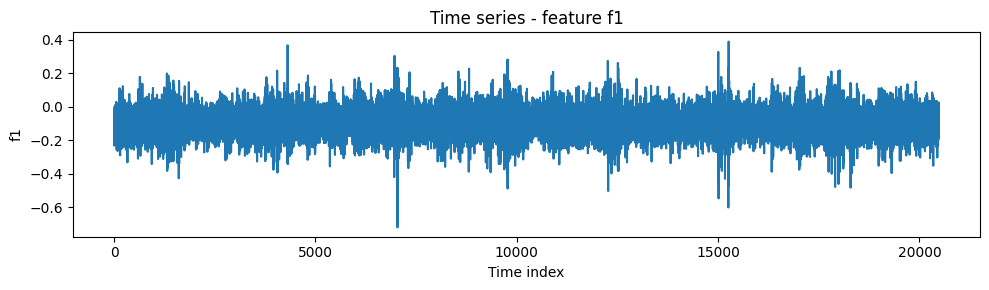

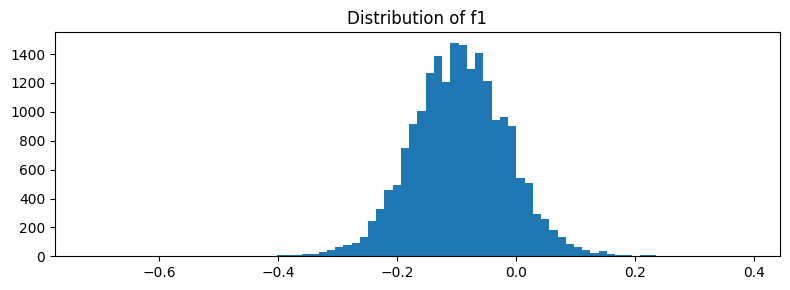

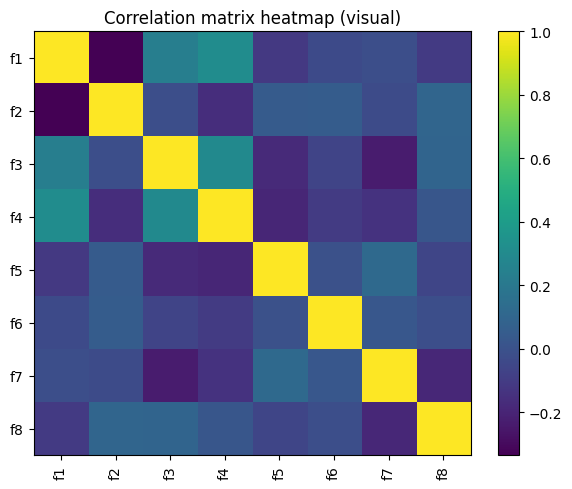


Top correlations (absolute) between feature pairs:
f2  f1    0.336001
f1  f4    0.312555
f3  f4    0.297300
    f1    0.233912
    f7    0.233409
f5  f4    0.190380
f8  f7    0.185806
f3  f5    0.176091
f4  f2    0.163426
f7  f4    0.140513

Feature matrix shape after engineering: (20480, 40)

Engineered features sample:
     f1  f1_rmean_5  f1_rstd_5  f1_diff1    f1_ewm     f2  f2_rmean_5  f2_rstd_5
-0.022   -0.022000   0.000000     0.000 -0.022000 -0.039   -0.039000   0.000000
-0.105   -0.063500   0.058690    -0.083 -0.065684 -0.017   -0.028000   0.015556
-0.183   -0.103333   0.080513    -0.078 -0.108974 -0.098   -0.051333   0.041885
-0.178   -0.122000   0.075600     0.005 -0.129046 -0.161   -0.078750   0.064624
-0.208   -0.139200   0.075932    -0.030 -0.148326 -0.129   -0.088800   0.060309

Scaled feature matrix shape: (20480, 40)

Isolation Forest detected anomalies: 205


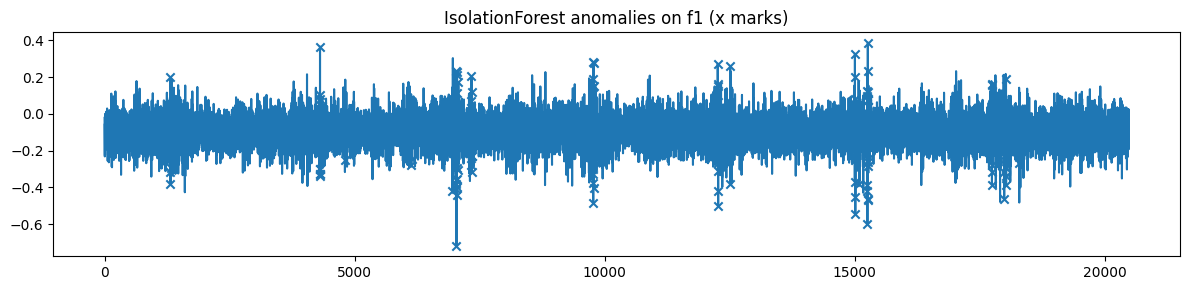


TensorFlow available; using Autoencoder approach.
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Autoencoder anomalies (top 1% by recon error): 205
Proxy anomalies by z-score (>3): 894

Metrics vs proxy labels (note: proxy labels are only a weak heuristic):
IsolationForest: {'precision': 0.8146341463414634, 'recall': 0.18680089485458612, 'f1': 0.3039126478616925, 'auc': np.float64(0.5924303667574268)}
Autoencoder/PCA: {'precision': 0.7609756097560976, 'recall': 0.174496644295302, 'f1': 0.28389444949954507, 'auc': np.float64(0.5859974286522972)}


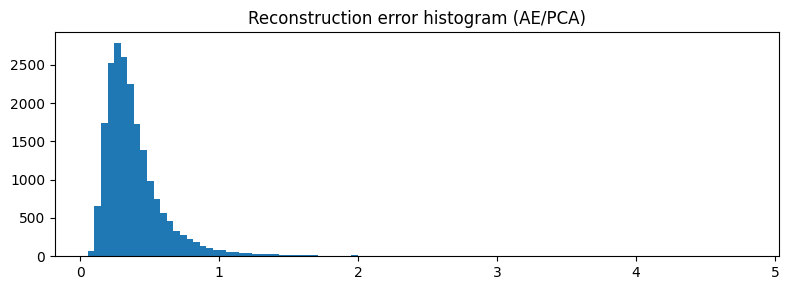


Overlap counts: both=127, iso_only=78, ae_only=78


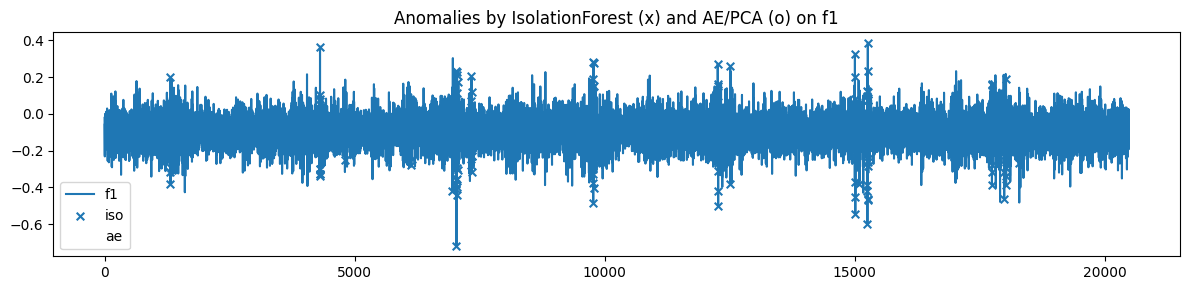


Saved results CSV to nasa_anomaly_results.csv


In [ ]:

# TASK:
# - Loaded the dataset from NASA.txt
# - Done EDA, missing values, stats, plots
# - Created rolling/statistical features, scale them
# - Ran two anomaly detection approaches: IsolationForest and Autoencoder
# - Provided visualizations and a basic proxy-evaluation using z-score extremes as pseudo-labels
#
# The outputs (plots, tables) will be shown to you by this notebook execution.

import os, io, sys, math, warnings
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
from matplotlib import pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, precision_recall_curve, auc

DATA_PATH = "NASA.txt"
assert os.path.exists(DATA_PATH)

# 1. Load dataset
df = pd.read_csv(DATA_PATH, sep=r'\s+', header=None, engine='python')
df.columns = [f"f{i+1}" for i in range(df.shape[1])]
print("Loaded dataset shape:", df.shape)
print(df.head().to_string(index=False))

# Basic stats
desc = df.describe().T
desc['nan_count'] = df.isna().sum(axis=0)
print("\nBasic stats (first 8 rows):\n", desc.head(8).to_string())

# Checking missing values
missing_total = df.isna().sum().sum()
print(f"\nTotal missing values in dataset: {missing_total}")

# Quick distribution overview (represented as table)
print("\nColumn means and stds:")
print(df.mean().round(4).to_frame("mean").join(df.std().round(4).to_frame("std")))

# EDA plots: time series for first feature, histogram, correlation heatmap
plt.figure(figsize=(10,3))
plt.plot(df['f1'])
plt.title("Time series - feature f1")
plt.xlabel("Time index")
plt.ylabel("f1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.hist(df['f1'], bins=80)
plt.title("Distribution of f1")
plt.tight_layout()
plt.show()

# Correlation heatmap (small)
corr = df.corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation matrix heatmap (visual)")
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.tight_layout()
plt.show()

print("\nTop correlations (absolute) between feature pairs:")
corr_unstack = corr.abs().unstack().sort_values(ascending=False).drop_duplicates()
print(corr_unstack[corr_unstack<1].head(10).to_string())

# 2. Feature engineering: rolling means/stds, diffs, ewm, and seasonal decomposition surrogate
df_fe = df.copy()
# Rolling windows (5, 20)
for w in [5, 20]:
    df_fe[[f"{c}_rmean_{w}" for c in df.columns]] = df.rolling(window=w, min_periods=1).mean().values
    df_fe[[f"{c}_rstd_{w}" for c in df.columns]] = df.rolling(window=w, min_periods=1).std().fillna(0).values

# First difference
df_fe[[f"{c}_diff1" for c in df.columns]] = df.diff().fillna(0).values

# EWMA (alpha=0.1)
df_fe[[f"{c}_ewm" for c in df.columns]] = df.ewm(alpha=0.1).mean().values

# Kept a reduced set of engineered features to control dimensionality
keep_cols = []
for c in df.columns:
    keep_cols += [c, f"{c}_rmean_5", f"{c}_rstd_5", f"{c}_diff1", f"{c}_ewm"]
df_features = df_fe[keep_cols].copy()
print("\nFeature matrix shape after engineering:", df_features.shape)

# Brief feature stats
print("\nEngineered features sample:\n", df_features.iloc[:5, :8].to_string(index=False))

#  Scaling
scaler = StandardScaler()
X = scaler.fit_transform(df_features)
print("\nScaled feature matrix shape:", X.shape)

# 3. Unsupervised Approach 1: Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso_labels = iso.fit_predict(X)  # -1 for anomaly, 1 for normal
iso_scores = -iso.decision_function(X)  # higher -> more anomalous
df['iso_score'] = iso_scores
df['iso_label'] = (iso_labels == -1).astype(int)
print("\nIsolation Forest detected anomalies:", df['iso_label'].sum())

# Visualize anomalies on f1 time series (IsolationForest)
plt.figure(figsize=(12,3))
plt.plot(df['f1'], label='f1')
anoms = df[df['iso_label']==1].index
plt.scatter(anoms, df.loc[anoms,'f1'], marker='x')
plt.title("IsolationForest anomalies on f1 (x marks)")
plt.tight_layout()
plt.show()

# 6. Deep approach: try Autoencoder (dense) using TensorFlow if available; fallback to PCA reconstruction error.
use_tf = False
try:
    import tensorflow as tf
    from tensorflow import keras
    use_tf = True
    print("\nTensorFlow available; using Autoencoder approach.")
except Exception as e:
    print("\nTensorFlow not available; will use PCA-based reconstruction as fallback for the 'deep' approach.")

recon_error = None
ae_labels = None
if use_tf:
    # Build a small dense autoencoder
    tf.random.set_seed(42)
    inp_dim = X.shape[1]
    model = keras.Sequential([
        keras.layers.Input(shape=(inp_dim,)),
        keras.layers.Dense(max(8, inp_dim//2), activation='relu'),
        keras.layers.Dense(max(4, inp_dim//4), activation='relu'),
        keras.layers.Dense(max(8, inp_dim//2), activation='relu'),
        keras.layers.Dense(inp_dim, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    # train on entire data (unsupervised)
    history = model.fit(X, X, epochs=30, batch_size=128, validation_split=0.1, verbose=0)
    # reconstruction
    X_pred = model.predict(X)
    recon_error = np.mean((X - X_pred)**2, axis=1)
    # mark anomalies as top 1% recon error
    thr = np.percentile(recon_error, 99)
    ae_labels = (recon_error > thr).astype(int)
    df['ae_recon_error'] = recon_error
    df['ae_label'] = ae_labels
    print("Autoencoder anomalies (top 1% by recon error):", ae_labels.sum())
else:
    # PCA fallback
    pca = PCA(n_components=min(10, X.shape[1]-1))
    Xp = pca.fit_transform(X)
    Xrec = pca.inverse_transform(Xp)
    recon_error = np.mean((X - Xrec)**2, axis=1)
    thr = np.percentile(recon_error, 99)
    ae_labels = (recon_error > thr).astype(int)
    df['ae_recon_error'] = recon_error
    df['ae_label'] = ae_labels
    print("PCA-reconstruction anomalies (top 1% recon error):", ae_labels.sum())

# 4. Proxy ground truth for evaluation: z-score extremes on any raw feature (abs z > 3) aggregated
from scipy import stats
z_scores = np.abs(stats.zscore(df[df.columns[:len(df.columns)-4]])) if df.shape[1]>4 else np.abs(stats.zscore(df[df.columns[:8]]))
# z_scores shape check - we want per-sample max z across original features
if isinstance(z_scores, np.ndarray):
    max_z = np.nanmax(z_scores, axis=1)
else:
    max_z = z_scores.max(axis=1).values
proxy_labels = (max_z > 3).astype(int)
df['proxy_label'] = proxy_labels
print("Proxy anomalies by z-score (>3):", df['proxy_label'].sum())

# Compute basic metrics using proxy labels as weak ground truth
def safe_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        aucroc = roc_auc_score(y_true, y_pred)
    except:
        aucroc = float('nan')
    return {"precision":p, "recall":r, "f1":f, "auc":aucroc}

metrics_iso = safe_metrics(df['proxy_label'], df['iso_label'])
metrics_ae = safe_metrics(df['proxy_label'], df['ae_label'])
print("\nMetrics vs proxy labels (note: proxy labels are only a weak heuristic):")
print("IsolationForest:", metrics_iso)
print("Autoencoder/PCA:", metrics_ae)

# 5. Visualization: reconstruction error histogram and overlap of labels
plt.figure(figsize=(8,3))
plt.hist(df['ae_recon_error'], bins=100)
plt.title("Reconstruction error histogram (AE/PCA)")
plt.tight_layout()
plt.show()

# Venn-like counts overlap
both = ((df['iso_label']==1) & (df['ae_label']==1)).sum()
iso_only = ((df['iso_label']==1) & (df['ae_label']==0)).sum()
ae_only = ((df['iso_label']==0) & (df['ae_label']==1)).sum()
print(f"\nOverlap counts: both={both}, iso_only={iso_only}, ae_only={ae_only}")

# Ploted f1 with both sets of anomalies marked
plt.figure(figsize=(12,3))
plt.plot(df['f1'], label='f1')
plt.scatter(df[df['iso_label']==1].index, df.loc[df['iso_label']==1,'f1'], marker='x', label='iso', s=30)
plt.scatter(df[df['ae_label']==1].index, df.loc[df['ae_label']==1,'f1'], marker='o', facecolors='none', label='ae', s=30)
plt.legend()
plt.title("Anomalies by IsolationForest (x) and AE/PCA (o) on f1")
plt.tight_layout()
plt.show()

# 5. Saved  results CSV with scores and labels
OUT_CSV = "nasa_anomaly_results.csv"
df[['f1','iso_score','iso_label','ae_recon_error','ae_label','proxy_label']].to_csv(OUT_CSV, index=False)
print("\nSaved results CSV to", OUT_CSV)


